In [56]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [57]:
##### I copied this from my in-class implementation #####

# The simulation might not use the entire 10,000 time steps if drift rate is high and decision is made early
def ddm_trial(v, a, beta, tau, dt=1e-3, scale=1.0, max_time=10.):
    """
    Simulates one realization of the diffusion process given
    a set of parameters and a step size `dt`.

    Parameters:
    -----------
    v     : float
        The drift rate (rate of information uptake)
    a     : float
        The boundary separation (decision threshold).
    beta  : float in [0, 1]
        Relative starting point (prior option preferences)
    tau   : float
        Non-decision time (additive constant)
    dt    : float, optional (default: 1e-3 = 0.001)
        The step size for the Euler algorithm.
    scale : float, optional (default: 1.0)
        The scale (sqrt(var)) of the Wiener process. Not considered
        a parameter and typically fixed to either 1.0 or 0.1.
    max_time: float, optional (default: .10)
        The maximum number of seconds before forced termination.

    Returns:
    --------
    (x, c) - a tuple of response time (y - float) and a 
        binary decision (c - int) 
    """

    # x = np.zeros(max_time/dt)
    # x[0] = beta

    x = beta * a # (not just beta bc need to scale w.r.t to boundary)
    t = 0

    while t < max_time :
        # We times the sqrt(dt) to the scale here to match euler-maruyama method
        # This is the formulation that allows us to discretize dt since it's incremental
        x += v * dt + scale * np.sqrt(dt) * np.random.standard_normal()
        if x >= a:
            c = 1
            return (t + tau, c)
        if x <= 0:
            c = 0
            return (t + tau, c)
        t = t + dt

    return (max_time, -1)


def ddm(num_sims, v, a, beta, tau, dt=1e-3, scale=1.0, max_time=10.):
    """Add a nice docstring."""

    data = np.zeros((num_sims, 2))
    for n in range(num_sims):
        data[n, :] = ddm_trial(v, a, beta, tau, dt, scale, max_time)
    return data


def visualize_diffusion_model(data, figsize=(8, 6)):
    """TODO: Add a nice docstring."""
    f, ax = plt.subplots(1, 1, figsize=figsize)
    sns.histplot(data[:, 0][data[:, 1] == 1], color='maroon', alpha=0.7, ax=ax, label='Correct responses')
    sns.histplot(data[:, 0][data[:, 1] == 0], color='gray', ax=ax, label='Incorrect responses')
    sns.despine(ax=ax)
    ax.set_xlabel('Response time (s)', fontsize=18)
    ax.set_ylabel('')
    ax.legend(fontsize=18)
    ax.set_yticks([])
    return f

In [ ]:
# Vary drift rate: v between [0.5,1.5]
v_list = np.linspace(0.5, 1.5, 25)
v_mean_differences = []

for v in v_list :

    params = {
        'v': float(v), # This is each v from the list above
        'a': 3, # all other parameters copied from in-class implementation
        'beta': 0.5,
        'tau': 0.7
    }

    ddm_data = ddm(2000, **params)

    ddm_correct = ddm_data[:, 0][ddm_data[:, 1] == 1]
    mean_correct = np.array(ddm_correct).mean()

    ddm_incorrect = ddm_data[:, 0][ddm_data[:, 1] == 0]
    mean_incorrect = np.array(ddm_incorrect).mean()

    v_mean_differences.append(mean_correct-mean_incorrect)

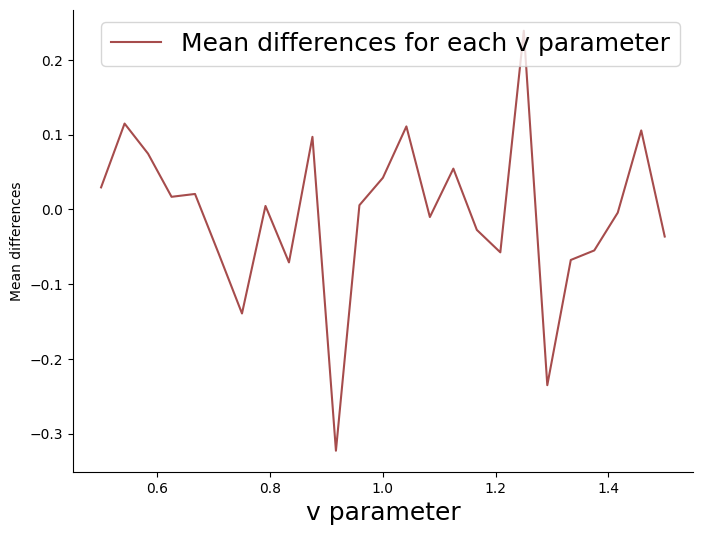

In [63]:
# Plot mean differences when varying v from 0.5 to 1.5

f, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.lineplot(x=v_list, y=v_mean_differences, color='maroon', alpha=0.7, ax=ax, label='Mean differences for each v parameter')
sns.despine(ax=ax)
ax.set_xlabel('v parameter', fontsize=18)
ax.set_ylabel('Mean differences')
ax.legend(fontsize=18)

In [ ]:
# Vary a between [1,5]
a_list = np.linspace(1, 5, 25)
a_mean_differences = []

for a in a_list :

    params = {
        'v': 1, # all other parameters copied from in-class implementation
        'a': float(a), # This is each a from the list above
        'beta': 0.5,
        'tau': 0.7
    }

    ddm_data = ddm(2000, **params)

    ddm_correct = ddm_data[:, 0][ddm_data[:, 1] == 1]
    mean_correct = np.array(ddm_correct).mean()

    ddm_incorrect = ddm_data[:, 0][ddm_data[:, 1] == 0]
    mean_incorrect = np.array(ddm_incorrect).mean()

    a_mean_differences.append(mean_correct-mean_incorrect)

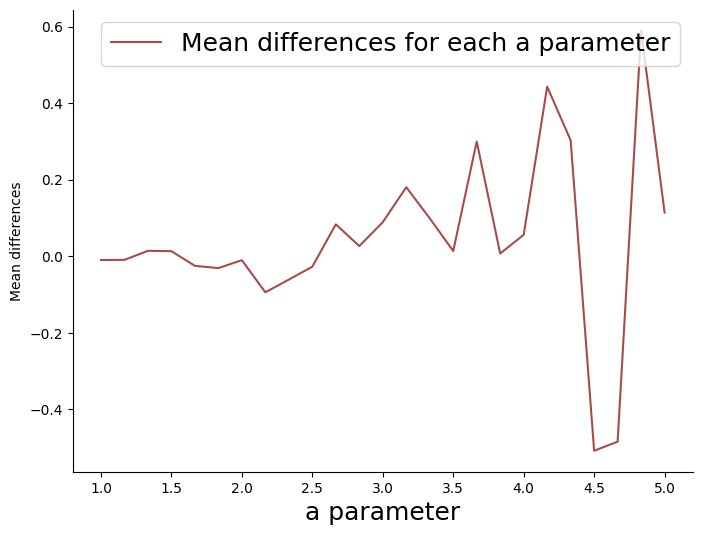

In [73]:
# Plot mean differences when varying v from 0.5 to 1.5

f, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.lineplot(x=a_list, y=a_mean_differences, color='maroon', alpha=0.7, ax=ax, label='Mean differences for each a parameter')
sns.despine(ax=ax)
ax.set_xlabel('a parameter', fontsize=18)
ax.set_ylabel('Mean differences')
ax.legend(fontsize=18)

In [68]:
# Vary bias: beta between [0.01,0.99]
beta_list = np.linspace(0.01, 0.99, 25)
beta_mean_differences = []

for beta in beta_list :

    params = {
        'v': 1, # all other parameters copied from in-class implementation
        'a': 3, 
        'beta': float(beta), # This is each beta from the list above
        'tau': 0.7
    }

    ddm_data = ddm(2000, **params)

    ddm_correct = ddm_data[:, 0][ddm_data[:, 1] == 1]
    mean_correct = np.array(ddm_correct).mean()

    ddm_incorrect = ddm_data[:, 0][ddm_data[:, 1] == 0]
    mean_incorrect = np.array(ddm_incorrect).mean()

    beta_mean_differences.append(mean_correct-mean_incorrect)

/var/folders/wp/tzpzwlds5jv4zlz56mynt1500000gn/T/ipykernel_31608/1839914419.py:20: RuntimeWarning: Mean of empty slice.
  mean_incorrect = np.array(ddm_incorrect).mean()
/opt/anaconda3/envs/stan311/lib/python3.11/site-packages/numpy/_core/_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


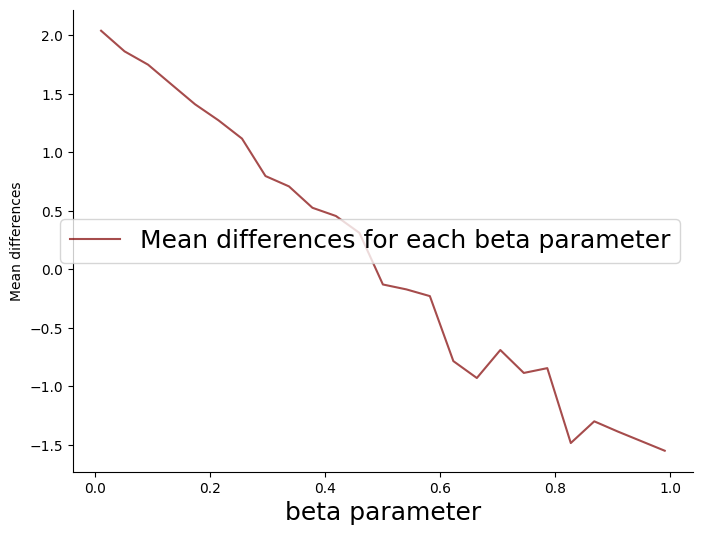

In [72]:
# Plot mean differences when varying beta from 0.01 to 0.99

f, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.lineplot(x=beta_list, y=beta_mean_differences, color='maroon', alpha=0.7, ax=ax, label='Mean differences for each beta parameter')
sns.despine(ax=ax)
ax.set_xlabel('beta parameter', fontsize=18)
ax.set_ylabel('Mean differences')
ax.legend(fontsize=18)

In [70]:
# Vary bias: tau between [0.5,1.5]
tau_list = np.linspace(0.5, 1.5, 25)
tau_mean_differences = []

for tau in tau_list :

    params = {
        'v': 1, # all other parameters copied from in-class implementation
        'a': 3, 
        'beta': 0.5, 
        'tau': float(tau) # This is each tau from the list above
    }

    ddm_data = ddm(2000, **params)

    ddm_correct = ddm_data[:, 0][ddm_data[:, 1] == 1]
    mean_correct = np.array(ddm_correct).mean()

    ddm_incorrect = ddm_data[:, 0][ddm_data[:, 1] == 0]
    mean_incorrect = np.array(ddm_incorrect).mean()

    tau_mean_differences.append(mean_correct-mean_incorrect)

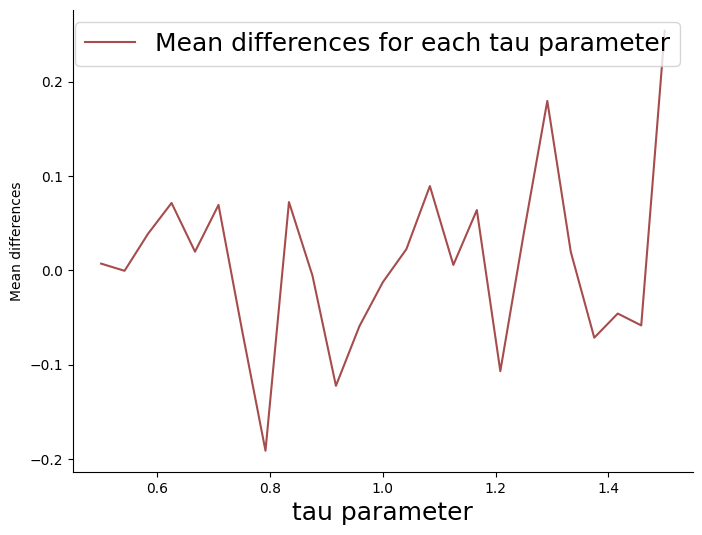

In [ ]:
# Plot mean differences when varying tau from 0.5 to 1.5

f, ax = plt.subplots(1, 1, figsize=(8, 6))
sns.lineplot(x=tau_list, y=tau_mean_differences, color='maroon', alpha=0.7, ax=ax, label='Mean differences for each tau parameter')
sns.despine(ax=ax)
ax.set_xlabel('tau parameter', fontsize=18)
ax.set_ylabel('Mean differences between correct and incorrect trials')
ax.legend(fontsize=18)